# 08. Crisis positions


In [1]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOPICS   = "speech_topic_assignments.csv"        # speech -> topic, from notebook 05
SPEECHES = "jina_v3_contrastive_full.parquet"    # one row per speech, fine-tuned encoder

PARTY_COLORS = {"CDU/CSU": "black", "SPD": "red", "Grüne": "green", "FDP": "gold",
                "LINKE": "purple", "AfD": "royalblue", "PDS": "darkorchid"}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Load

In [2]:
topics_df = pd.read_csv(TOPICS)[["speech_id", "topic_emb_full_name"]]
df = pd.read_parquet(SPEECHES, columns=["id", "politicianId", "party", "year", "embedding"])

df = df.merge(topics_df, left_on="id", right_on="speech_id", how="inner")
#drop Fraktionslos
df = df[(df.party != "Fraktionslos") & (df.politicianId != -1)].copy()
df["E"] = df.embedding.map(lambda v: np.asarray(v, dtype="float32"))

ALL_TOPICS = sorted(df.topic_emb_full_name.unique())
print(f"{len(df):,} speeches | {len(ALL_TOPICS)} topics | years {df.year.min()}-{df.year.max()}")
print(df.party.value_counts().to_string())

81,916 speeches | 72 topics | years 2000-2021
party
CDU/CSU    24032
SPD        18064
Grüne      14868
LINKE      10836
FDP        10381
AfD         2638
PDS         1097


## 2. Events and their topics


In [3]:
#Each event carries an explicit list of topics from notebook 05, manually chosen by reading the topic labels
EVENTS = [
    #Afghanistan topics stand in for 9/11, since corpus records the parliamentary consequences rather thnn the attack
    dict(date="2001-09-11", label="9/11 terror attacks", kind="crisis", topics=[
        "isaf-mandats/isaf-mission/karzai",
        "ramstein/kunduz/drohnen"]),
    dict(date="2008-09-15", label="Lehman collapse / financial crisis", kind="crisis", topics=[
        "pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch"]),
    dict(date="2011-03-11", label="Fukushima nuclear disaster", kind="crisis", topics=[
        "schwarzelühr-sutter/reaktorsicherheit/reaktoren",
        "entsorgungskonzept/salzstocks/sellafield",
        "erdverkabelung/netznutzungsentgelte/übertragungsnetzbetreibern"]),
    dict(date="2016-01-01", label="Migration scepticism (post-Cologne NYE)", kind="crisis", topics=[
        "mehrstaatigkeit/dublin-ii-verordnung/optionspflicht"]),
    #Brexit has no topic of its own, the closest topic is the EU trade-policy topic (CETA), which is a weak proxy
    dict(date="2016-06-23", label="Brexit referendum", kind="crisis", topics=[
        "handelsgerichtshof/investorenschutz/ceta"]),          # proxy: EU trade policy, no Brexit topic
    dict(date="2016-11-08", label="Trump elected US president", kind="election", topics=[
        "antiamerikanismus/transatlantischen/transatlantische"]),
    dict(date="2020-03-22", label="COVID-19 (first German lockdown)", kind="crisis", topics=[
        "impfkampagne/astrazeneca/geimpfte"]),
]

for ev in EVENTS:
    ev["year"] = int(ev["date"][:4])
#checks that every name still exists in the data, so a re-run of BERTopic would raise an error rather than silently analysing nothing.
unknown = {t for ev in EVENTS for t in ev["topics"]} - set(ALL_TOPICS)
if unknown:
    raise ValueError(f"topic name(s) not found in the data: {unknown}")
print("all topic names found in the data\n")

for ev in EVENTS:
    n = df.topic_emb_full_name.isin(ev["topics"]).sum()
    print(f"{ev['date']}  {ev['label']}")
    for t in ev["topics"]:
        print(f"     - {t}")
    print(f"     {n:,} speeches in total\n")

all topic names found in the data

2001-09-11  9/11 terror attacks
     - isaf-mandats/isaf-mission/karzai
     - ramstein/kunduz/drohnen
     2,206 speeches in total

2008-09-15  Lehman collapse / financial crisis
     - pfandbrief/vermögensanlagen/kapitalanlagegesetzbuch
     1,624 speeches in total

2011-03-11  Fukushima nuclear disaster
     - schwarzelühr-sutter/reaktorsicherheit/reaktoren
     - entsorgungskonzept/salzstocks/sellafield
     - erdverkabelung/netznutzungsentgelte/übertragungsnetzbetreibern
     3,777 speeches in total

2016-01-01  Migration scepticism (post-Cologne NYE)
     - mehrstaatigkeit/dublin-ii-verordnung/optionspflicht
     2,913 speeches in total

2016-06-23  Brexit referendum
     - handelsgerichtshof/investorenschutz/ceta
     702 speeches in total

2016-11-08  Trump elected US president
     - antiamerikanismus/transatlantischen/transatlantische
     716 speeches in total

2020-03-22  COVID-19 (first German lockdown)
     - impfkampagne/astrazeneca/gei

The topics differ a lot in size, and that limits what each event can carry. Fukushima has three
topics and 3,777 speeches behind it, COVID only 1,020 and Brexit 702. Small topics move sharply
from year to year simply because a handful of debates land in one year rather than the next, so
the thin events are read for their level, not for their wiggles.

## 3. Does attention change around the event?

Two views per event.

**Attention over time.** The share of all speeches in a year that fall on the
event's topics. If a crisis reorganises the agenda, this is where it shows up most directly.

**Who is doing the talking.** For each party, the share of *its own* speeches
devoted to those topics, in the three years before and the three years after the event. Using
each party's own denominator means a party that simply speaks more often does not appear more
interested.

**Share of each party's speeches on topic**

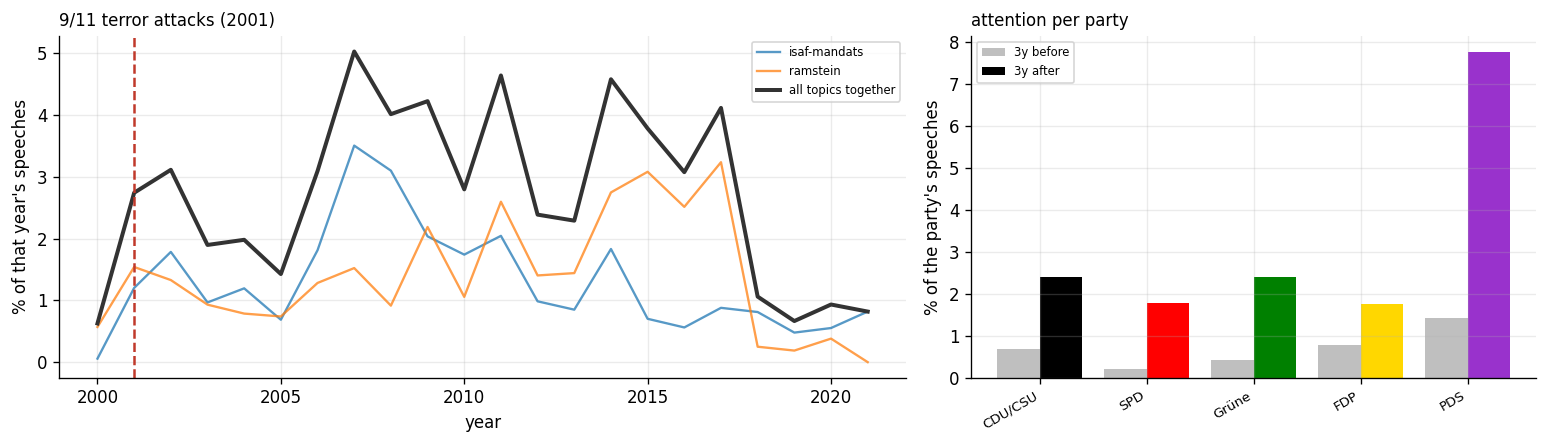

share of each party's speeches on these topics, % — 9/11 terror attacks
         isaf-mandats  ramstein
party                          
AfD              0.72      0.34
CDU/CSU          1.29      0.56
FDP              1.34      0.54
Grüne            1.36      2.54
LINKE            1.45      3.92
PDS              1.28      2.83
SPD              1.27      0.57 



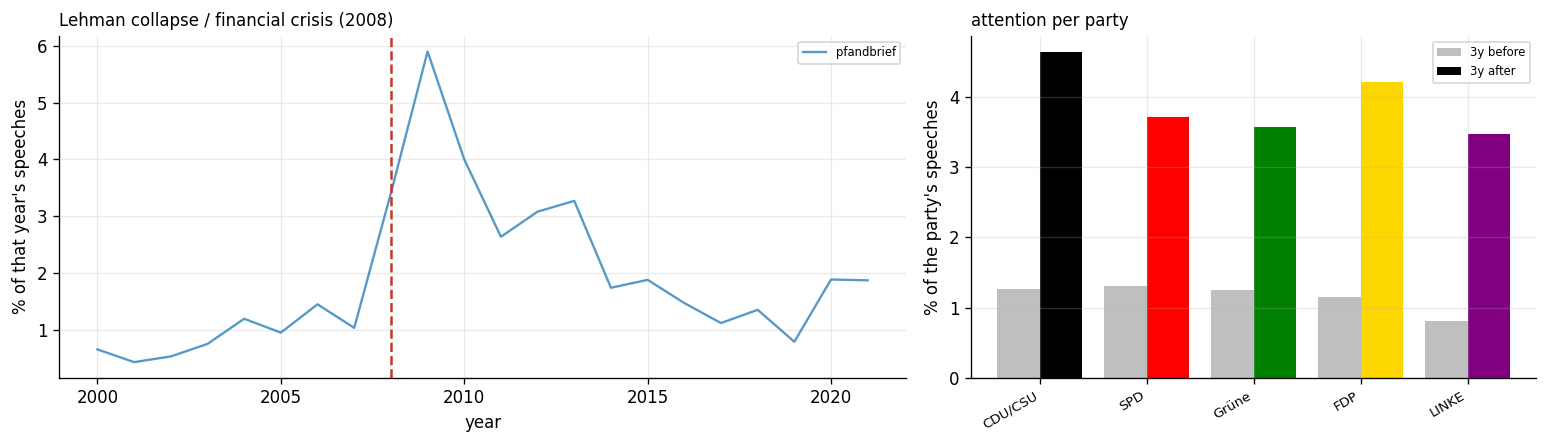

share of each party's speeches on these topics, % — Lehman collapse / financial crisis
         pfandbrief
party              
AfD            1.21
CDU/CSU        2.05
FDP            2.11
Grüne          1.84
LINKE          1.97
PDS            0.36
SPD            2.15 



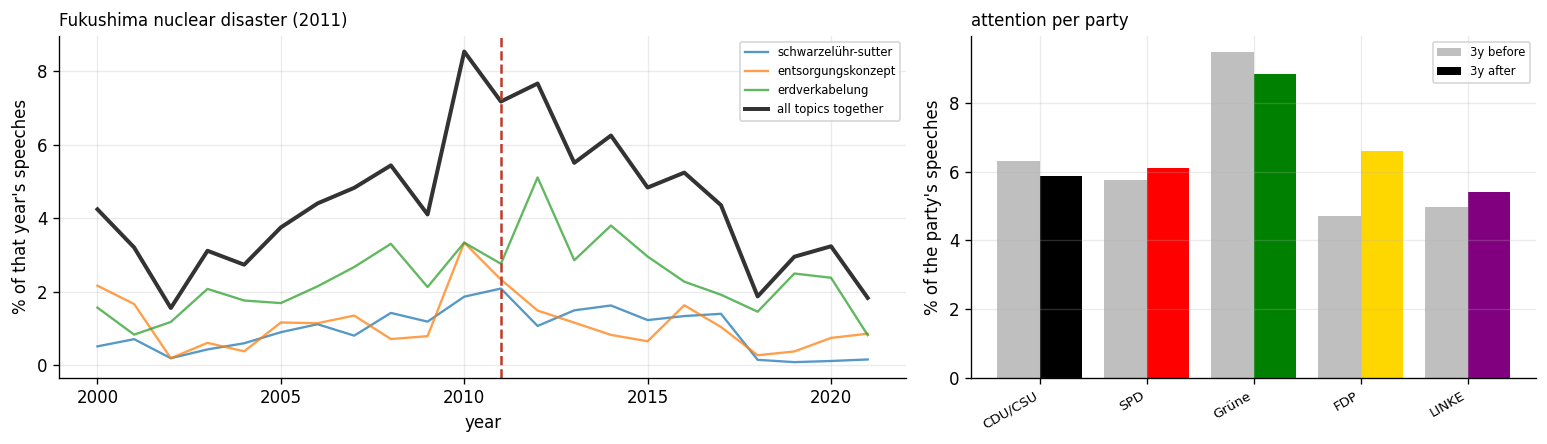

share of each party's speeches on these topics, % — Fukushima nuclear disaster
         entsorgungskonzept  erdverkabelung  schwarzelühr-sutter
party                                                           
AfD                    0.68            1.74                 0.30
CDU/CSU                1.23            2.54                 0.44
FDP                    1.07            2.32                 0.43
Grüne                  1.10            2.97                 2.57
LINKE                  1.14            2.13                 1.12
PDS                    1.46            0.73                 0.73
SPD                    1.28            2.51                 0.64 



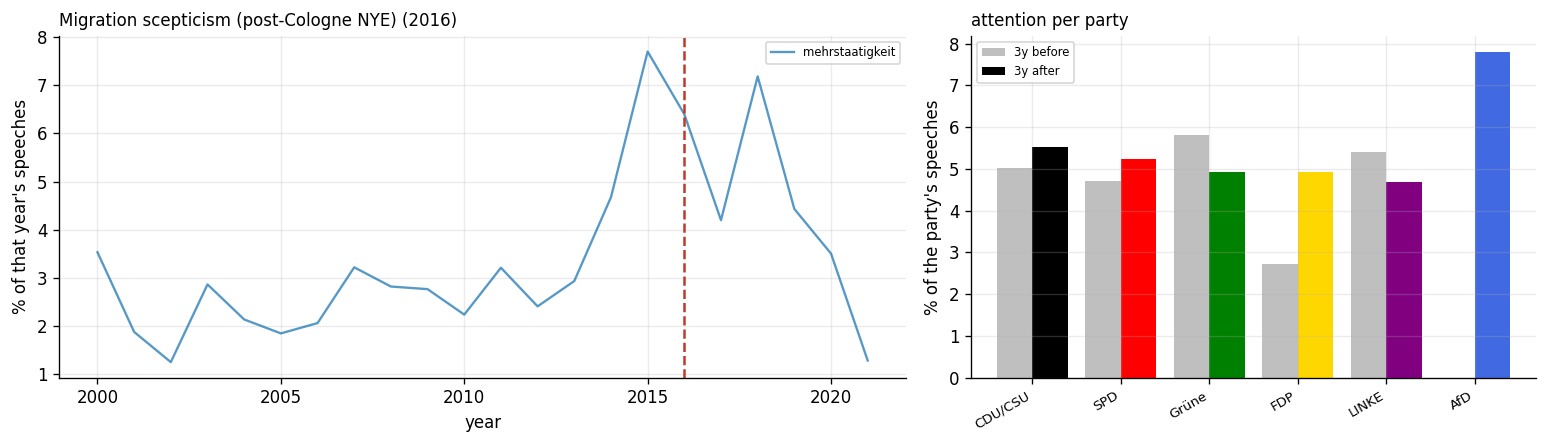

share of each party's speeches on these topics, % — Migration scepticism (post-Cologne NYE)
         mehrstaatigkeit
party                   
AfD                 6.03
CDU/CSU             3.43
FDP                 2.70
Grüne               4.04
LINKE               4.13
PDS                 2.10
SPD                 3.19 



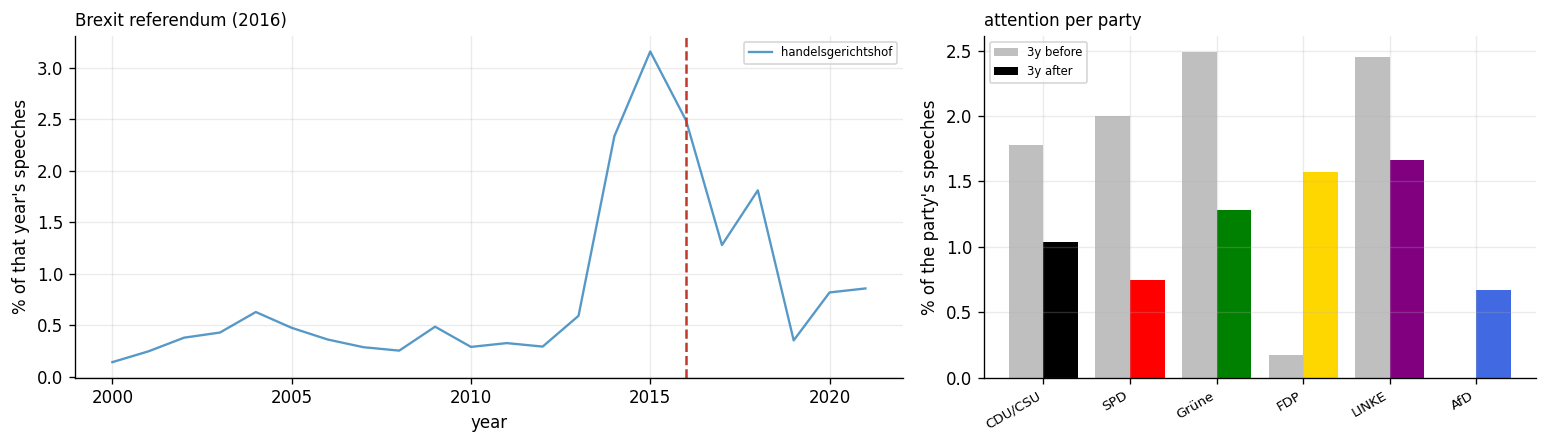

share of each party's speeches on these topics, % — Brexit referendum
         handelsgerichtshof
party                      
AfD                    0.72
CDU/CSU                0.85
FDP                    0.58
Grüne                  1.06
LINKE                  1.21
PDS                     NaN
SPD                    0.72 



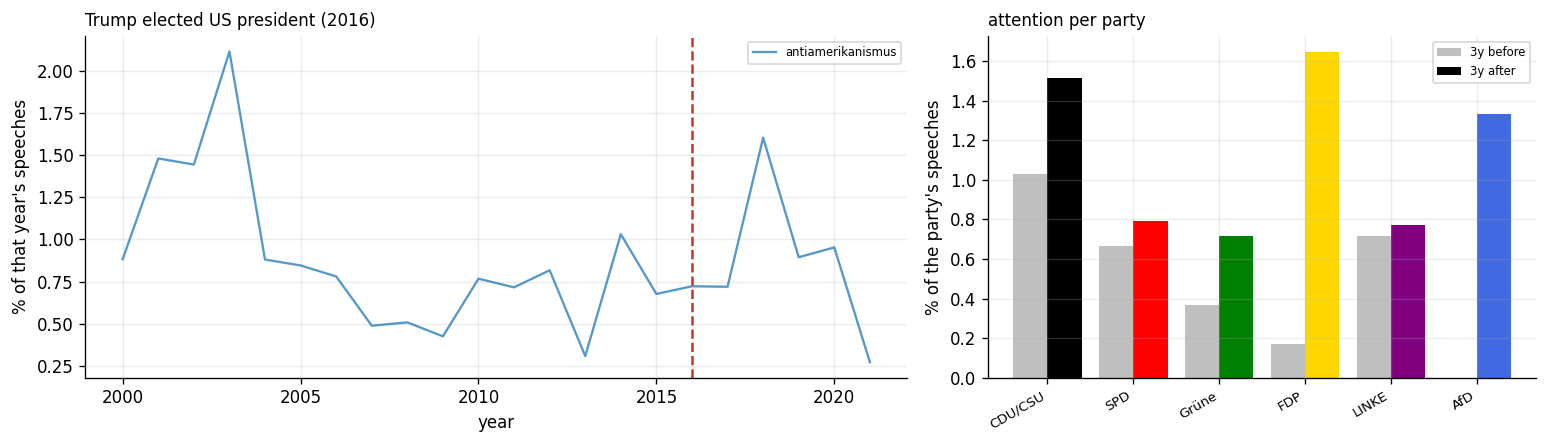

share of each party's speeches on these topics, % — Trump elected US president
         antiamerikanismus
party                     
AfD                   0.95
CDU/CSU               1.10
FDP                   1.03
Grüne                 0.61
LINKE                 0.56
PDS                   1.19
SPD                   0.86 



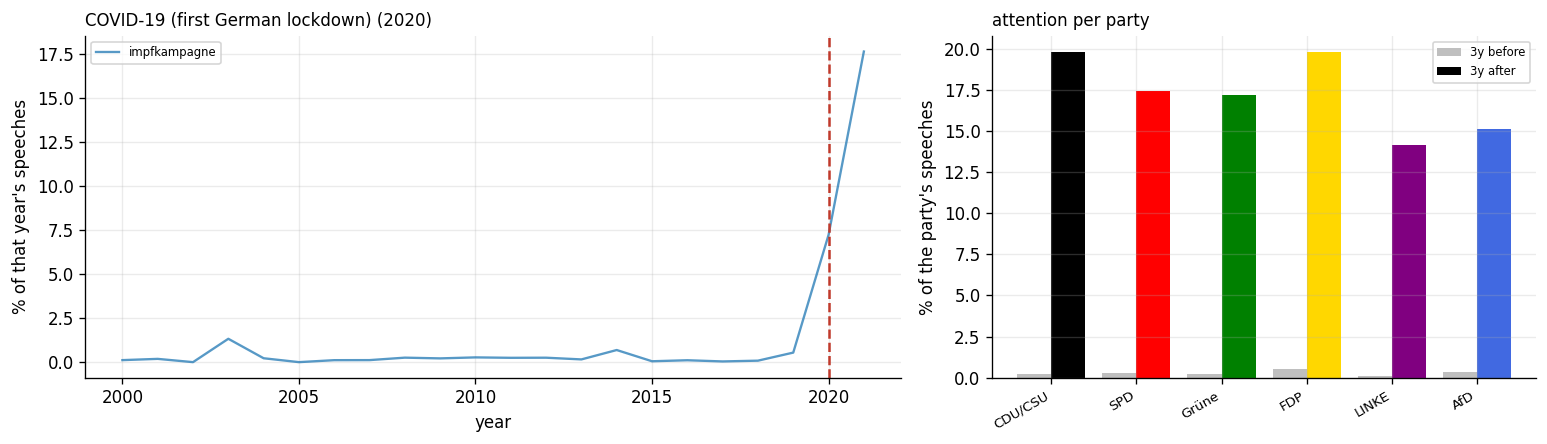

share of each party's speeches on these topics, % — COVID-19 (first German lockdown)
         impfkampagne
party                
AfD              4.44
CDU/CSU          1.30
FDP              1.57
Grüne            0.85
LINKE            0.97
PDS              0.18
SPD              1.07 



In [4]:
WINDOW = 3      # years before / after the event used for the party comparison

def frequency_figure(ev):
    "Attention to an event's topics: over time, and per party before vs after."
    on_topic = df.topic_emb_full_name.isin(ev["topics"])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8),
                                   gridspec_kw={"width_ratios": [1.5, 1]})

    # --- left: share of the year's speeches, one line per topic plus the total
    for t in ev["topics"]:
        share = df.topic_emb_full_name.eq(t).groupby(df.year).mean()
        ax1.plot(share.index, 100 * share.values, lw=1.4, alpha=.75,
                 label=t.split("/")[0][:22])
    if len(ev["topics"]) > 1:
        tot = on_topic.groupby(df.year).mean()
        ax1.plot(tot.index, 100 * tot.values, lw=2.4, color="0.2", label="all topics together")
    ax1.axvline(ev["year"], color="#c0392b", ls="--", lw=1.5)
    ax1.set_xlabel("year"); ax1.set_ylabel("% of that year's speeches")
    ax1.set_title(f"{ev['label']} ({ev['year']})", loc="left", fontsize=10)
    ax1.legend(fontsize=7)

    # --- right: per party, share of its own speeches, before vs after
    pre  = df[df.year.between(ev["year"] - WINDOW, ev["year"] - 1)]
    post = df[df.year.between(ev["year"] + 1, ev["year"] + WINDOW)]
    parties = [p for p in PARTY_COLORS if p in set(pre.party) | set(post.party)]
    b = [100 * pre.loc[pre.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    a = [100 * post.loc[post.party == p, "topic_emb_full_name"].isin(ev["topics"]).mean()
         for p in parties]
    x = np.arange(len(parties))
    ax2.bar(x - 0.2, b, 0.4, color="0.75", label=f"{WINDOW}y before")
    ax2.bar(x + 0.2, a, 0.4, color=[PARTY_COLORS[p] for p in parties], label=f"{WINDOW}y after")
    ax2.set_xticks(x); ax2.set_xticklabels(parties, rotation=30, ha="right", fontsize=8)
    ax2.set_ylabel("% of the party's speeches")
    ax2.set_title("attention per party", loc="left", fontsize=10)
    ax2.legend(fontsize=7)

    plt.tight_layout()
    slug = "".join(ch if ch.isalnum() else "_" for ch in ev["label"].lower())[:28]
    plt.savefig(f"fig_freq_{ev['year']}_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # --- the same numbers as a table: party x topic, share of the party's speeches
    d = df[on_topic]
    tab = (100 * pd.crosstab(d.party, d.topic_emb_full_name).div(
           df.groupby("party").size(), axis=0)).round(2)
    tab.columns = [c.split("/")[0][:22] for c in tab.columns]
    print(f"share of each party's speeches on these topics, % — {ev['label']}")
    print(tab.to_string(), "\n")
    return tab


for ev in EVENTS:
    frequency_figure(ev)

*Interpretation.* Only three of the seven events actually reorganise the agenda.

**COVID** is the sharpest break in the whole corpus: the topic sits flat at about 0.2% for
twenty years, jumps to 7.3% in 2020 and 17.6% in 2021. Every party lands between 14% and 20% of
its own speeches — including the AfD at 15.1%, which is not an outlier here. Note the topic is
labelled *Impfkampagne/AstraZeneca*, so it is really the vaccination debate, which is why 2021 is
higher than the lockdown year itself.

**Lehman** is the textbook case: 1.0% in 2007, 3.4% in 2008, 5.9% in 2009, then a slow decay back
to about 1.8%. All five parties roughly triple, from around 1.2% to between 3.5% and 4.7%. Nobody
owns the crisis — that is what a pure agenda effect looks like.

**9/11** raises attention from 0.6% to 2.8% within a year, but what stays on the agenda for two
decades is the mandate cycle, not the attack: the peaks are 2007 (5.0%) and 2011 (4.6%), the
years of contested ISAF renewals, and the collapse after 2017 is the withdrawal. The PDS bar of
7.8% should be ignored — after 2002 the PDS held only two direct mandates, so the denominator is
a few dozen speeches. The table is the more reliable read: on *ramstein/kunduz* the LINKE (3.92%)
and the Grüne (2.54%) speak four to seven times as much as CDU/CSU, SPD and FDP (about 0.55%),
while on *isaf-mandats* everyone sits between 1.27% and 1.45%. The mandate debate is compulsory
for all; the critique of the deployment is a left-wing topic.

**Fukushima does not fit the crisis pattern.** The peak is 2010, the year *before* the disaster,
at 8.5%. That is the Laufzeitverlängerung of autumn 2010. Fukushima arrived into a debate that
was already running at full volume, and attention afterwards (7.7% in 2012) never gets back to
the 2010 level. The party panel says the same thing: the Grüne go from 9.4% to 8.8%, slightly
*down*, and nobody else moves much. Nuclear power was always their topic.

**Migration** peaks in 2015 at 7.7%, a year before the Cologne New Year's Eve that dates the
event here — the summer of 2015 is the real break, with a second peak in 2018. The AfD devotes
7.8% of its speeches to it, more than anyone, but the others are not far behind at 4.7–5.5%.

**Brexit and Trump are not measurable with these topics.** The CETA proxy behaves like CETA and
not like Brexit: it peaks in 2015 during the TTIP negotiations and *falls* after the referendum,
for every party. The Trump topic shows no break at all in 2016; its all-time high is 2003, the
Iraq war, and the 2018 bump is more plausibly the tariff and NATO-spending disputes. The FDP's
apparent jump from 0.17% to 1.65% is an artefact — the party was out of parliament from 2013 to
2017, so its "before" bar rests on 2013 alone.

One caveat on the tables: they are computed over the whole 2000–2021 period, so they describe a
party's general profile on the topic rather than its behaviour around the event. The bars in the
right panel are the ones restricted to the ±3-year windows.

## 4. Positions — only where an axis can be anchored

- yearly mean is subtracted so a drift shared by all parties cannot look like movement;
- the axis is estimated on the years *before* the event so the ruler does not move with the data; and the result is rescaled so the two anchor parties sit at 0 and 1 in that reference period, which makes a value of 0.4 readable
as "40% of the way from one party's position to the other's".


In [5]:
def positions(topic_names, left, right, ref_years):
    "Party-year positions on the left->right axis, rescaled so left=0 and right=1 before the event."
    d = df[df.topic_emb_full_name.isin(topic_names)]

    # 1. aggregate to party-year, no threshold
    py = pd.DataFrame([dict(party=p, year=y, n=len(g),
                            E=np.mean(np.stack(g.E.to_numpy()), axis=0))
                       for (p, y), g in d.groupby(["party", "year"])])

    # a year with one party is useless: the yearly mean is that party, so demeaning gives 0
    per_year = py.groupby("year").size()
    lonely = per_year[per_year < 2].index.tolist()
    if lonely:
        print(f"years with only one party, dropped: {lonely}")
        py = py[~py.year.isin(lonely)]

    # 2. subtract the yearly mean
    ymu = {y: np.mean(np.stack(g.E.to_numpy()), axis=0) for y, g in py.groupby("year")}
    py["Ed"] = [e - ymu[y] for e, y in zip(py.E, py.year)]

    # 3. axis from the reference (pre-event) years only
    ref = py[py.year.isin(ref_years)]
    for anchor in (left, right):
        if not (ref.party == anchor).any():
            raise ValueError(f"{anchor} has no speech in the reference years {list(ref_years)}")
    a = (np.mean(np.stack(ref.loc[ref.party == right, "Ed"].to_numpy()), axis=0)
         - np.mean(np.stack(ref.loc[ref.party == left,  "Ed"].to_numpy()), axis=0))
    axis = a / np.linalg.norm(a)

    # 4. project, then rescale so the anchors sit at 0 and 1 in the reference period
    py["raw"] = [float(e @ axis) for e in py.Ed]
    lo = py.loc[py.year.isin(ref_years) & (py.party == left),  "raw"].mean()
    hi = py.loc[py.year.isin(ref_years) & (py.party == right), "raw"].mean()
    py["pos"] = (py.raw - lo) / (hi - lo)
    return py.sort_values(["party", "year"])


def plot_positions(py, event_year, left, right, title):
    fig, ax = plt.subplots(figsize=(9.5, 4.6))
    ax.axhline(0, color=PARTY_COLORS.get(left, "0.4"), ls=":", lw=1.4)
    ax.axhline(1, color=PARTY_COLORS.get(right, "0.4"), ls=":", lw=1.4)
    ax.axvline(event_year, color="#c0392b", ls="--", lw=1.5)
    for p, g in py.groupby("party"):
        g = g.sort_values("year")
        col = PARTY_COLORS.get(p, "grey")
        # break the line where a year is missing, so a gap is not drawn as a smooth move
        run = []
        for r in g.itertuples():
            if run and r.year - run[-1][0] > 1:
                ax.plot(*zip(*run), "-", color=col, lw=1.8)
                run = []
            run.append((r.year, r.pos))
        if len(run) > 1:
            ax.plot(*zip(*run), "-", color=col, lw=1.8)
        # marker size shows how many speeches are behind the point
        ax.scatter(g.year, g.pos, s=6 + 1.6 * g.n, color=col, zorder=4, label=p,
                   edgecolor="white", linewidth=.6)
    ax.set_xlabel("year")
    ax.set_ylabel(f"position on the {left} → {right} axis\n(0 = {left}, 1 = {right} before the event)")
    ax.set_title(title + "   (marker size = speeches behind the point)", loc="left", fontsize=10)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    return ax

### Fukushima — did the Union move toward the Greens?

The clearest test case, because the answer is documented outside the corpus: after March 2011
the CDU/CSU reversed course and legislated the nuclear phase-out it had extended only months
earlier. If the embeddings carry policy content, the Union should move upward after 2011. The
axis is estimated on 2005–2010.

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0       50   21     16      0   15   47
2001     0       37   13     16      0   13   25
2002     0       11   10      3      0    4   13
2003     0       40   15     13      0    0   19
2004     0       41   10     15      0    0   21
2005     0       38    9     10      0    0   14
2006     0       36   20     51     21    0   30
2007     0       43   25     43     23    0   34
2008     0       52   23     66     26    0   47
2009     0       36   17     39     23    0   20
2010     0      101   53    116     51    0   91
2011     0       86   48     86     59    0   72
2012     0       93   60     71     55    0   87
2013     0       50   27     58     32    0   47
2014     0       70    0    115     43    0   45
2015     0       44    0     83     30    0   36
2016     0       51    0     65     42    0   38
2017     2       24    3     39     25    0 

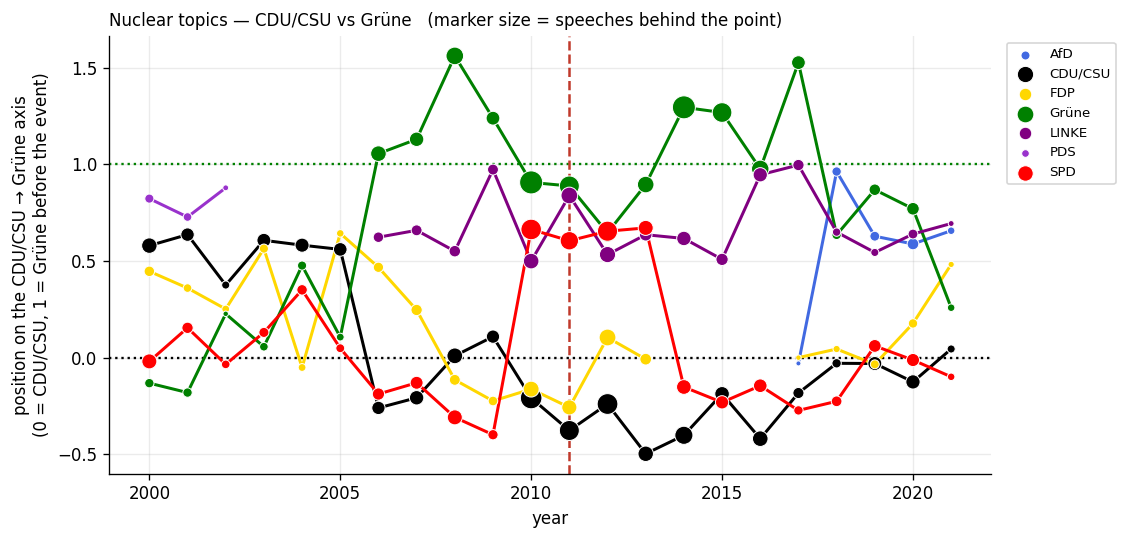

         2007-2010  2012-2015  shift
party                               
CDU/CSU      -0.07      -0.33  -0.26
FDP          -0.06       0.05   0.11
Grüne         1.21       1.03  -0.18
LINKE         0.67       0.57  -0.10
SPD          -0.04       0.24   0.28


In [6]:
NUCLEAR = next(e for e in EVENTS if "Fukushima" in e["label"])["topics"]

py_nuc = positions(NUCLEAR, left="CDU/CSU", right="Grüne", ref_years=range(2005, 2011))
print("speeches per party-year:")
print(py_nuc.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_nuc, 2011, "CDU/CSU", "Grüne", "Nuclear topics — CDU/CSU vs Grüne")
plt.savefig("fig_fukushima.png", dpi=150, bbox_inches="tight"); plt.show()

before = py_nuc[py_nuc.year.between(2007, 2010)].groupby("party").pos.mean()
after  = py_nuc[py_nuc.year.between(2012, 2015)].groupby("party").pos.mean()
print(pd.DataFrame({"2007-2010": before, "2012-2015": after,
                    "shift": after - before}).round(2).to_string())

*Interpretation.* Read the plot from 2006 onwards only. Before 2005 the ordering is inverted —
CDU/CSU sits near 0.6 and the Grüne near −0.1 — which is a warning, not a finding: the axis is
estimated on 2005–2010 and evidently does not transport back into the red-green years. From 2006
on the ranking is stable and plausible: Grüne between 0.9 and 1.5, LINKE between 0.5 and 1.0,
SPD, FDP and Union around zero or below. So the direction does separate the parties.

The hypothesis still fails. The Union does not move toward the Greens after Fukushima; it moves
away, from −0.07 to −0.33. The parties that move upward are the SPD (+0.28) and the FDP (+0.11),
and the SPD's timing gives the likely reason: it sits at 0.66 in 2010 and 2011, fighting the
lifetime extension from the opposition benches, and drops back to about −0.15 once it is in the
grand coalition from 2014. What the axis tracks looks more like an opposition-versus-government
register than a position on nuclear power.

That fits what happened to the topic. Once the phase-out became consensus, the nuclear debate
turned into grid expansion and final storage — the *erdverkabelung* topic is the largest of the
three from 2012 on — and there the Union speaks as the government that has to implement it. The
Merkel Wende is a policy reversal that left almost no trace in plenary language, which is a
genuine limit of the method rather than a result about the CDU/CSU.

### Migration — where do the parties sit relative to the AfD?

The AfD only enters the Bundestag in 2017, so the axis has to be estimated *after* the event
rather than before it. That weakens the reading considerably: we can see the ordering of the
parties from 2017 onward, but not how they stood relative to a party that did not yet exist.

Anchors: Grüne und AfD

speeches per party-year:
party  AfD  CDU/CSU  FDP  Grüne  LINKE  PDS  SPD
year                                            
2000     0       29   29     22      0   14   30
2001     0       23    8      8      0    5   17
2002     0       10    3      9      0    4    7
2003     0       41    8      8      0    0   23
2004     0       31   12      7      0    0   18
2005     0       11    6      8      0    0   10
2006     0       17   11     18     16    0   12
2007     0       21   11     23     36    0   21
2008     0       23   12     30     23    0   23
2009     0       20   16     18     19    0   18
2010     0       29   17     19     27    0   16
2011     0       40   26     40     22    0   29
2012     0       24   21     26     20    0   24
2013     0       30   16     24     24    0   20
2014     0       51    0     62     43    0   48
2015     0      100    0     87     61    0   59
2016     0       76    0     69     45    0   49
2017     9       28    7     27     18    0 

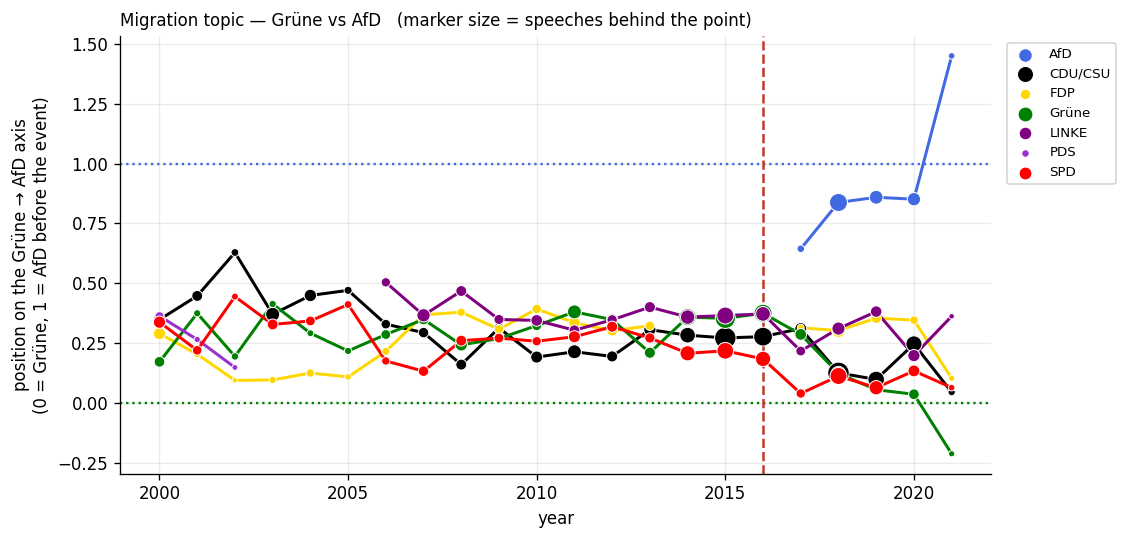

In [7]:
MIGRATION = next(e for e in EVENTS if "Migration" in e["label"])["topics"]

py_mig = positions(MIGRATION, left="Grüne", right="AfD", ref_years=range(2018, 2022))
print("speeches per party-year:")
print(py_mig.pivot(index="year", columns="party", values="n").fillna(0).astype(int).to_string())

plot_positions(py_mig, 2016, "Grüne", "AfD", "Migration topic — Grüne vs AfD")
plt.savefig("fig_migration.png", dpi=150, bbox_inches="tight"); plt.show()

*Interpretation.* The AfD separates cleanly, sitting at 0.64–0.86 from 2017 while every other
party stays between 0.0 and 0.4. But look at what that means: before 2017 all parties, the Grüne
included, sit bunched at 0.2–0.4 with no stable ordering between them. The axis has not found a
migration-policy scale on which the house can be ranked — it has found "AfD language versus
everyone else". By this measure the CDU/CSU is no closer to the AfD than the SPD is.

Two things not to over-read. The whole left half of the plot lies outside the reference period,
so the pre-2017 positions are projections onto a ruler built from years these parties had not yet
reached. And the 2021 endpoints (Grüne at −0.21, AfD at 1.45) rest on five and six speeches — the
electoral term ends in September, so the year is a stub.